<a href="https://colab.research.google.com/github/leonnmarcoo/CCDEPLRL_EXERCISES_COM232/blob/main/Fashion_MNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Import**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

print("TensorFlow version", tf.__version__)

TensorFlow version 2.19.0


## **Load Dataset**

In [ ]:
fasion_mnist = tf.keras.datasets.fashion_mnist
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

print ("Training set: ", x_train.shape, y_train.shape)


Training set:  (60000, 28, 28) (60000,)


## **Visualize a few samples**

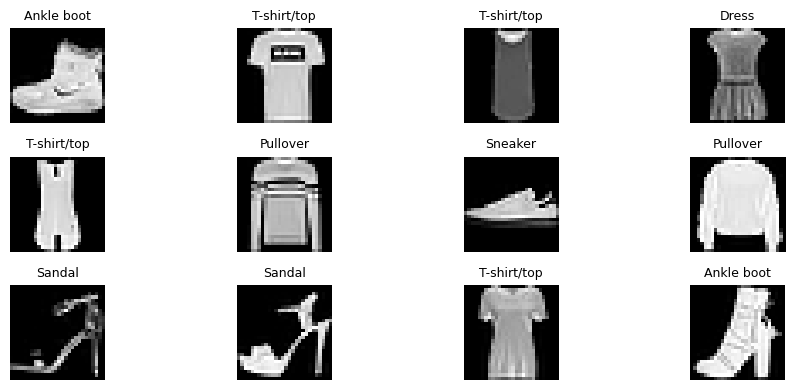

In [ ]:
plt.figure(figsize=(10, 4))
for i in range(12):
  plt.subplot(3, 4, i+1)
  plt.imshow(x_train[i], cmap = "gray")
  plt.title(class_names[y_train[i]], fontsize = 9)
  plt.axis("off")
plt.tight_layout()
plt.show()

## **Preprocess**

In [ ]:
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

## **Model**

In [ ]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28, 28)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation = "relu"),
    tf.keras.layers.Dense(10, activation = "softmax")
])

model.compile (
    optimizer = "adam",
    loss = "sparse_categorical_crossentropy",
    metrics = ["accuracy"]
)

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

## **Train**

In [ ]:
history = model.fit (
    x_train, y_train,
    epochs = 8,
    validation_split = 0.2

)

Epoch 1/8
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8198 - loss: 0.5136 - val_accuracy: 0.8493 - val_loss: 0.4191
Epoch 2/8
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.8610 - loss: 0.3857 - val_accuracy: 0.8579 - val_loss: 0.3897
Epoch 3/8
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8745 - loss: 0.3435 - val_accuracy: 0.8687 - val_loss: 0.3617
Epoch 4/8
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.8837 - loss: 0.3163 - val_accuracy: 0.8738 - val_loss: 0.3465
Epoch 5/8
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.8899 - loss: 0.2986 - val_accuracy: 0.8676 - val_loss: 0.3746
Epoch 6/8
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8935 - loss: 0.2839 - val_accuracy: 0.8817 - val_loss: 0.3304
Epoch 7/8
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9005 - loss: 0.2690 - val_accuracy: 0.8897 - val_loss: 0.3079
Epoch 8/8
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9040 - loss: 0.2574 - val_accu

## **Plot**

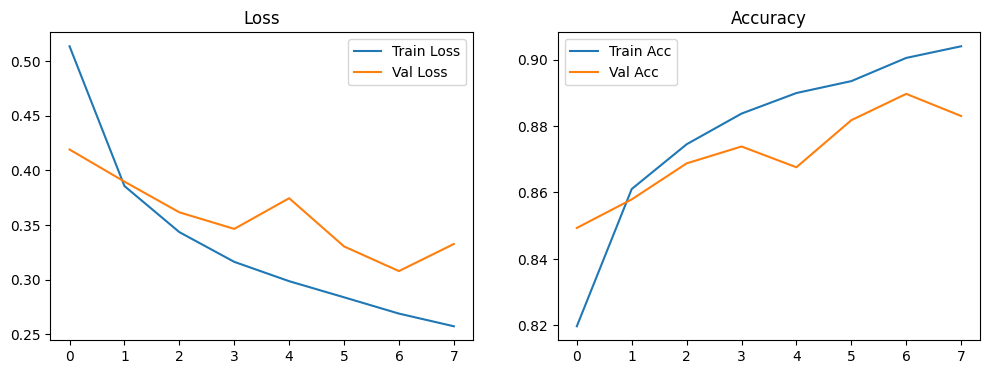

In [ ]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.legend()
plt.title("Loss")

plt.subplot(1,2,2)
plt.plot(history.history["accuracy"], label="Train Acc")
plt.plot(history.history["val_accuracy"], label="Val Acc")
plt.legend()
plt.title("Accuracy")

plt.show()

## **Evaluate**

In [ ]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose = 0)
print(f"Test accuracy: {test_acc:.4f}")

Test accuracy: 0.8723


## **Prediction**

In [ ]:
pred_probs = model.predict(x_test, verbose=0)
pred_labels = np.argmax(pred_probs, axis=1)

## **Show Prediction**

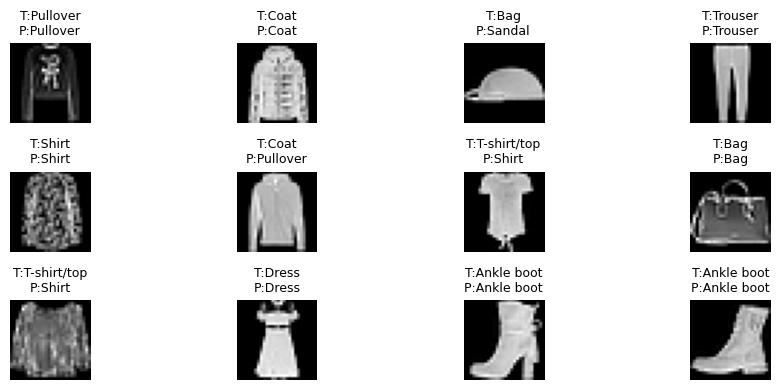

In [ ]:
def show_predictions(n=12):
    plt.figure(figsize=(10,4))
    idxs = np.random.choice(len(x_test), n, replace=False)
    for i, idx in enumerate(idxs):
        plt.subplot(3,4,i+1)
        plt.imshow(x_test[idx], cmap="gray")
        true_name = class_names[y_test[idx]]
        pred_name = class_names[pred_labels[idx]]
        title = f"T:{true_name}\nP:{pred_name}"
        plt.title(title, fontsize=9)
        plt.axis("off")
    plt.tight_layout()
    plt.show()

show_predictions(12)

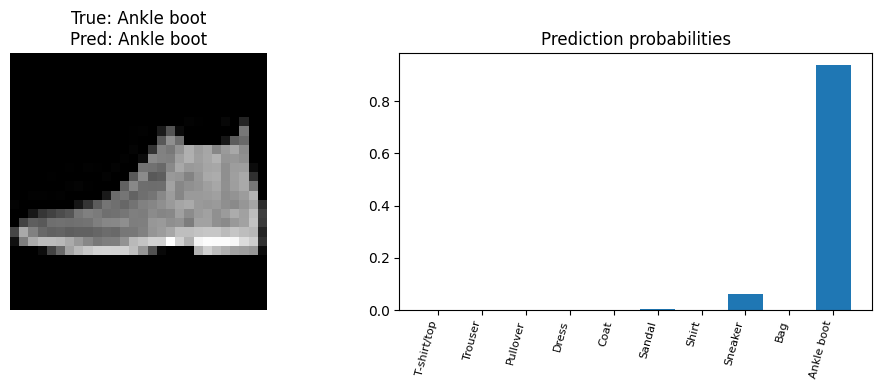

In [ ]:
def predict_one(index):
    img = x_test[index]
    true = y_test[index]
    probs = model.predict(img[np.newaxis, ...], verbose=0)[0]
    pred = np.argmax(probs)

    plt.figure(figsize=(10,4))

    plt.subplot(1,2,1)
    plt.imshow(img, cmap="gray")
    plt.title(f"True: {class_names[true]}\nPred: {class_names[pred]}")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.bar(range(10), probs)
    plt.xticks(range(10), class_names, rotation=75, ha="right", fontsize=8)
    plt.title("Prediction probabilities")
    plt.tight_layout()
    plt.show()

predict_one(0)